In [1]:
import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import pairwise_distances
from collections import Counter

Chargement des annotations de drogues...
-> 542 correspondances chargées avec succès.

Lecture des fichiers modèles .joblib...
-> 485 fichiers trouvés.


/usr/lib/python3.13/pickle.py:1760: UserWarning: [16:06:01] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)



 Calcul de la matrice de similarité (Indice de Jaccard)...


/home/sbodin/.local/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2474: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


-> Après filtrage (seuil >= 0.001), il reste 485 modèles.
 34 modèles filtrés n'ont pas de pathway associé (classés en 'Autre').

Génération du Clustermap final...


/home/sbodin/.local/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/sbodin/.local/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Terminé avec succès ! Graphique disponible ici : Test1_Heatmap_melanome_pathways.png


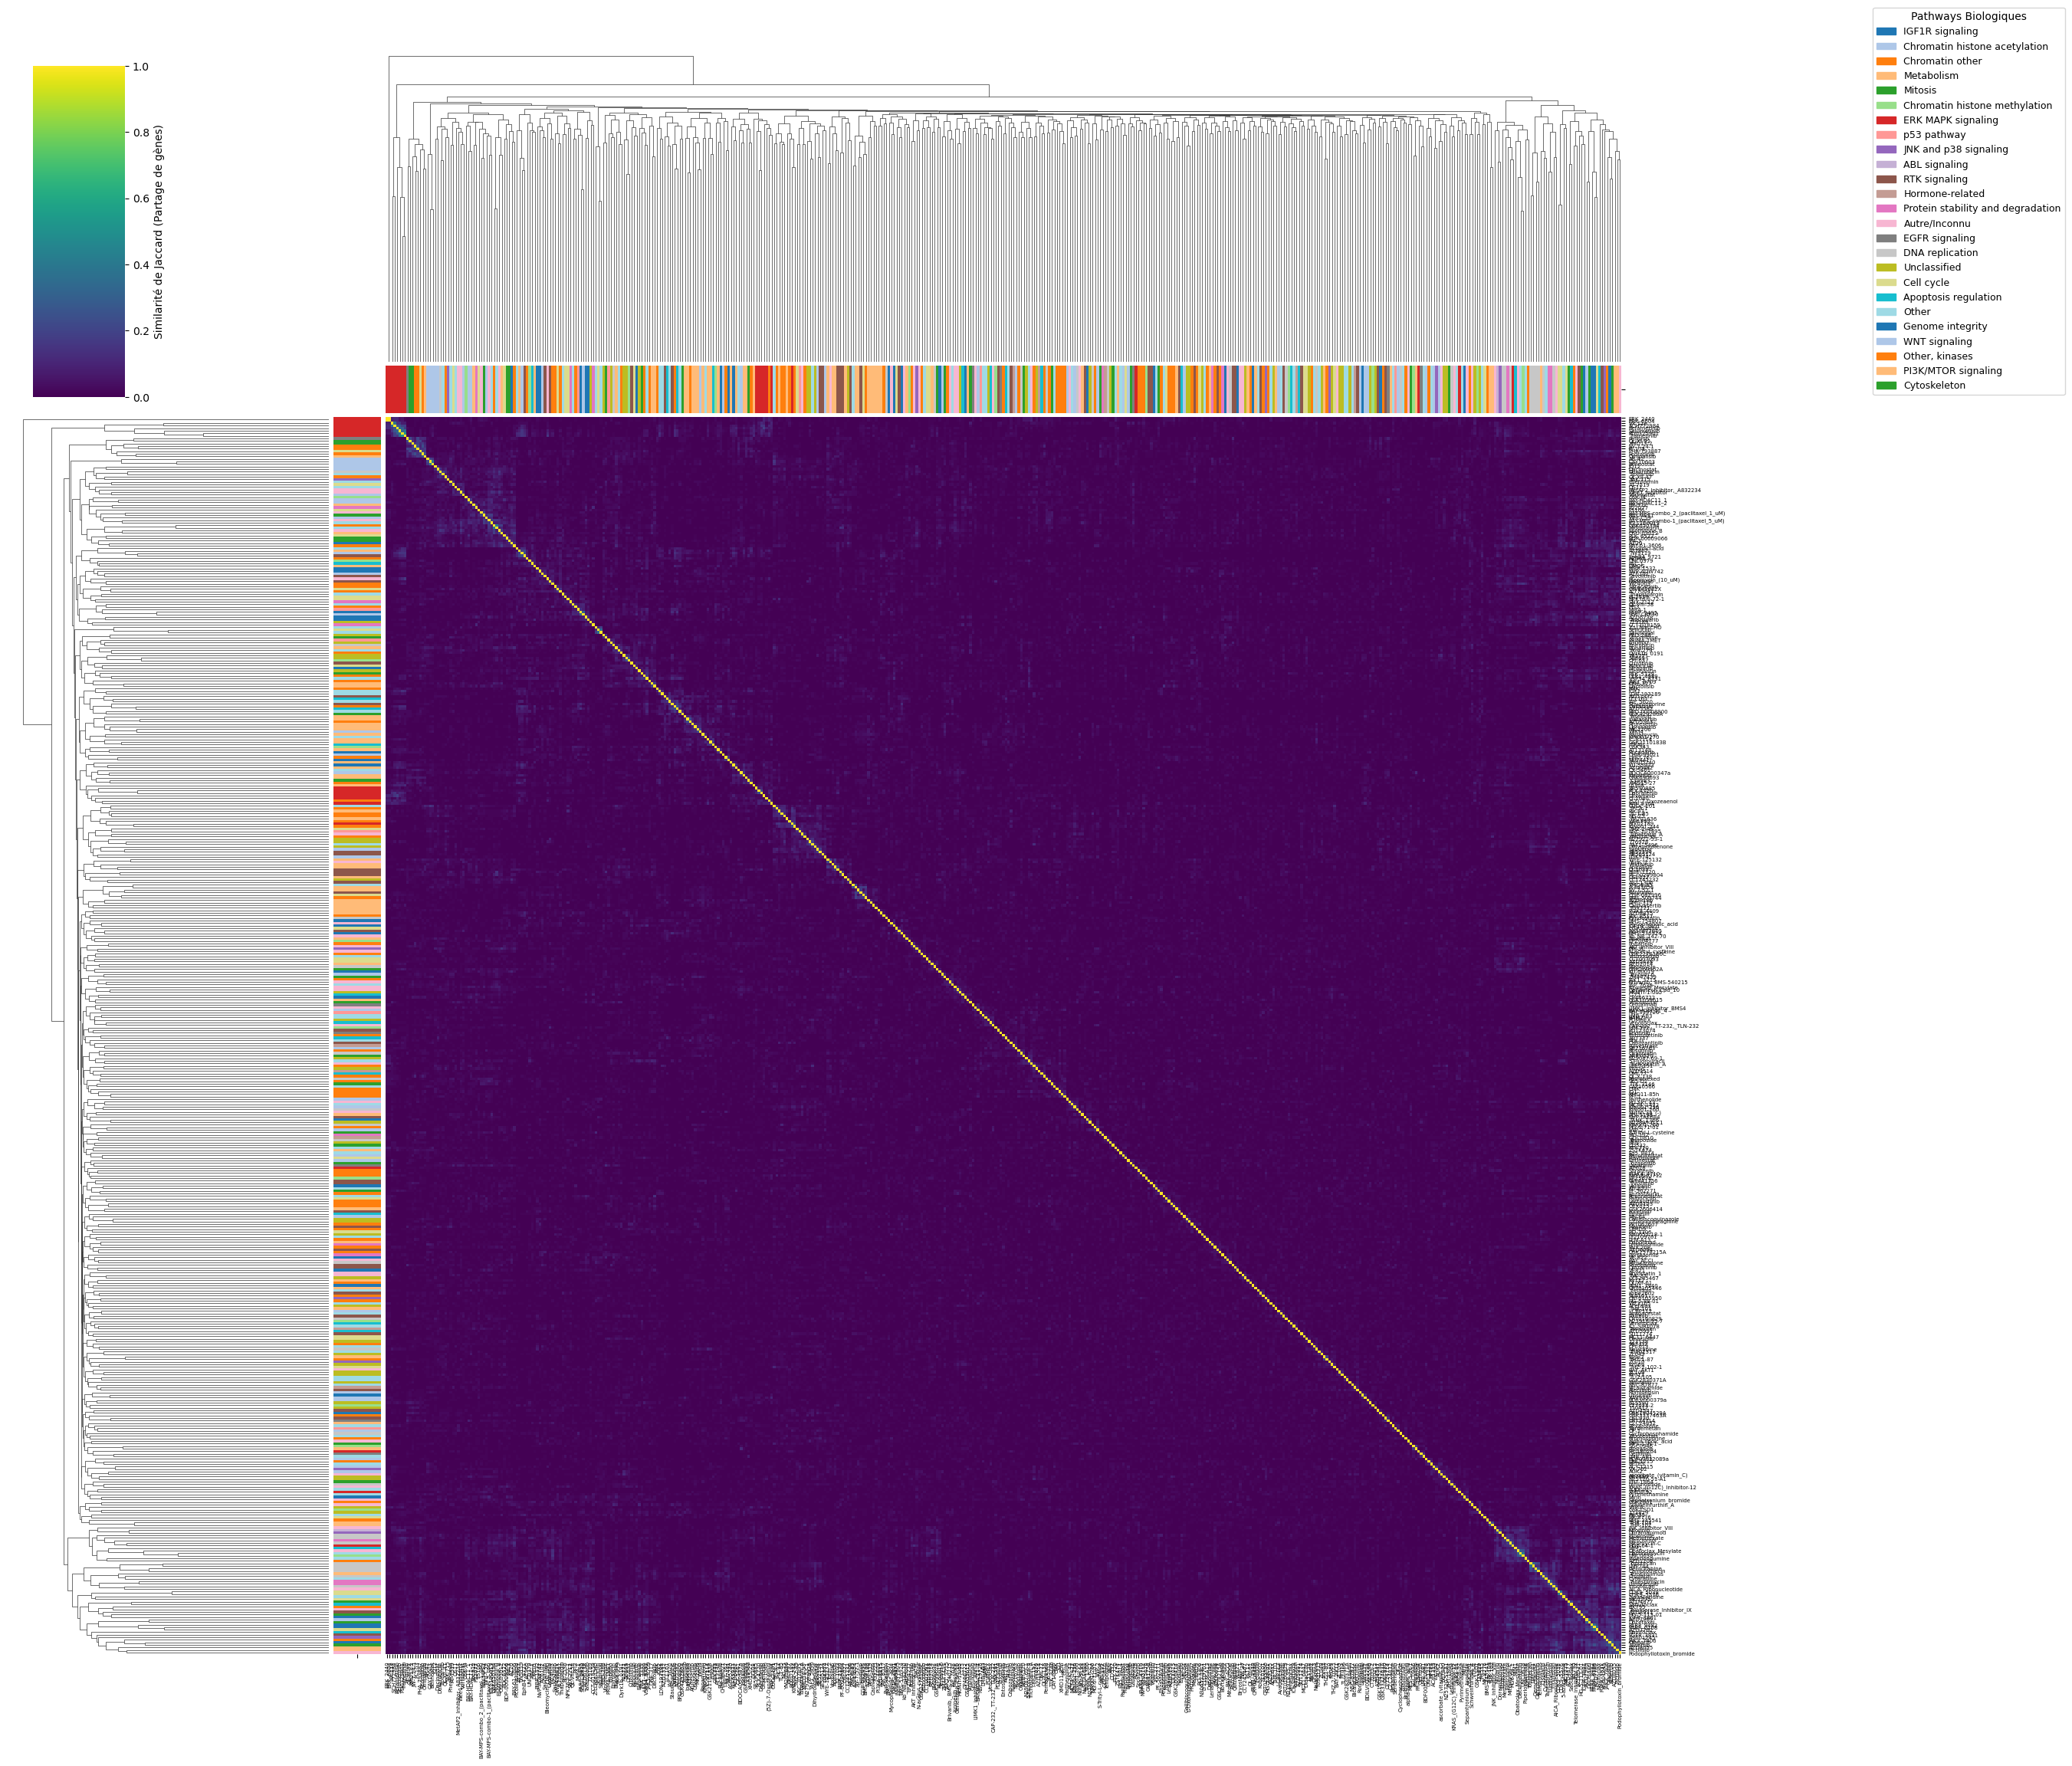

In [ ]:
models_dir = "models_test1/" # Répertoire contenant les modèles .joblib
annotations_file = "data/Dataset_3groups.csv"
output_image_path = "Test1_Heatmap_melanome_pathways.png"

# Paramètres d'analyse
SEUIL_SIMILARITE = 0.001
colonne_drug = "DRUG_NAME"  
colonne_pathway = "PATHWAY_NAME"  

print("Chargement des annotations de drogues...")
try:
    df_annotations = pd.read_csv(annotations_file)
    df_annotations[colonne_drug] = df_annotations[colonne_drug].str.strip()
    df_annotations[colonne_pathway] = df_annotations[colonne_pathway].str.strip()
    drug_to_pathway = dict(zip(df_annotations[colonne_drug], df_annotations[colonne_pathway]))
    print(f"-> {len(drug_to_pathway)} correspondances chargées avec succès.")
except Exception as e:
    print(f"Erreur lors de la lecture du fichier d'annotations : {e}")
    print("Vérifie le chemin de ton fichier ou le nom de tes colonnes.")
    raise

print("\nLecture des fichiers modèles .joblib...")
file_pattern = os.path.join(models_dir, "*.joblib")
joblib_files = glob.glob(file_pattern)
print(f"-> {len(joblib_files)} fichiers trouvés.")

model_features = {}
for filepath in joblib_files:
    model_name = os.path.basename(filepath).replace(".joblib", "")
    try:
        model_data = joblib.load(filepath)
        if 'selected_features' in model_data:
            model_features[model_name] = set(model_data['selected_features'])
        else:
            print(f"Clé 'selected_features' absente dans : {model_name}")
    except Exception as e:
        print(f"Erreur de lecture sur {model_name}: {e}")

# Calcul JACCARD
print("\n Calcul de la matrice de similarité (Indice de Jaccard)...")
all_genes = sorted(list(set().union(*model_features.values())))
model_names = list(model_features.keys())

binary_data = np.zeros((len(model_features), len(all_genes)), dtype=int)
for i, model in enumerate(model_names):
    for j, gene in enumerate(all_genes):
        if gene in model_features[model]:
            binary_data[i, j] = 1

df_binary = pd.DataFrame(binary_data, index=model_names, columns=all_genes)
jaccard_dist = pairwise_distances(df_binary.values, metric="jaccard")
df_similarity = pd.DataFrame(1 - jaccard_dist, index=model_names, columns=model_names)

matrix_sans_diagonale = df_similarity.copy()
np.fill_diagonal(matrix_sans_diagonale.values, 0)
modeles_a_garder = matrix_sans_diagonale.index[(matrix_sans_diagonale >= SEUIL_SIMILARITE).any(axis=1)]
df_filtrée = df_similarity.loc[modeles_a_garder, modeles_a_garder]

print(f"-> Après filtrage (seuil >= {SEUIL_SIMILARITE}), il reste {len(df_filtrée)} modèles.")

if len(df_filtrée) == 0:
    print("Aucun modèle ne passe le filtre. Baisse la valeur de SEUIL_SIMILARITE.")
else:
    manquants = [drug for drug in df_filtrée.index if drug not in drug_to_pathway]
    if manquants:
        print(f" {len(manquants)} modèles filtrés n'ont pas de pathway associé (classés en 'Autre').")
    
    pathways_presents = list(set(drug_to_pathway.get(drug, "Autre/Inconnu") for drug in df_filtrée.index))
    
    palette = sns.color_palette("tab20", len(pathways_presents))
    pathway_colors_dict = dict(zip(pathways_presents, palette))
    
    df_colors = pd.Series(df_filtrée.index, index=df_filtrée.index).map(
        lambda x: pathway_colors_dict.get(drug_to_pathway.get(x, "Autre/Inconnu"))
    )

    print("\nGénération du Clustermap final...")
    taille_fig = max(12, min(24, len(df_filtrée) * 0.35))
    
    g = sns.clustermap(
        df_filtrée,
        cmap="viridis",        
        vmin=0, vmax=1,        
        xticklabels=True,  
        yticklabels=True,  
        row_colors=df_colors,  
        col_colors=df_colors,  
        figsize=(taille_fig, taille_fig),
        cbar_kws={'label': 'Similarité de Jaccard (Partage de gènes)'}
    )
    
    # Légende des pathways
    legend_handles = [
        mpatches.Patch(color=color, label=pathway) 
        for pathway, color in pathway_colors_dict.items()
    ]
    g.ax_col_dendrogram.legend(
        handles=legend_handles, 
        title="Pathways Biologiques", 
        loc='center left', 
        bbox_to_anchor=(1.2, 0.5),
        fontsize=9
    )
    
    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=max(5, min(9, 300/len(df_filtrée))))
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=max(5, min(9, 300/len(df_filtrée))))
    
    g.savefig(output_image_path, dpi=300, bbox_inches='tight')
    print(f"Terminé avec succès ! Graphique disponible ici : {output_image_path}")

In [3]:
def get_strict_intersection(file_paths):
    """
    Renvoie la liste des gènes strictement communs à tous les fichiers joblib spécifiés.
    """
    if not file_paths:
        print("Erreur : La liste des fichiers est vide.")
        return []
    
    first_model = joblib.load(file_paths[0])
    common_genes = set(first_model['selected_features'])
    
    print(f"Modèle 1 ({file_paths[0]}) : {len(common_genes)} gènes.")

    for i, path in enumerate(file_paths[1:], start=2):
        model_data = joblib.load(path)
        genes_set = set(model_data['selected_features'])
        print(f"Modèle {i} ({path}) : {len(genes_set)} gènes.")
        
        common_genes = common_genes.intersection(genes_set)
        
    common_genes_list = list(common_genes)
    print(f"\n=> Nombre de gènes strictement en commun : {len(common_genes_list)}")
    return common_genes_list


In [ ]:
fichiers = [
     "Models/Other_models/Trametinib.joblib",
     "Models/Other_models/PD0325901.joblib",
     "Models/Other_models/Selumetinib.joblib",
     "Models/Other_models/Refametinib.joblib",
     "Models/Other_models/SCH772984.joblib",
     #"Models/Other_models/VX-11e.joblib",
     #"Models/Other_models/Dabrafenib.joblib",
 ]
genes_communs = get_strict_intersection(fichiers)
print("Gènes partagés :", genes_communs)

Modèle 1 (models_test1/Trametinib.joblib) : 50 gènes.
Modèle 2 (models_test1/PD0325901.joblib) : 50 gènes.
Modèle 3 (models_test1/Selumetinib.joblib) : 50 gènes.
Modèle 4 (models_test1/Refametinib.joblib) : 50 gènes.
Modèle 5 (models_test1/SCH772984.joblib) : 50 gènes.

=> Nombre de gènes strictement en commun : 10
Gènes partagés : ['NKILA', 'CNR1', 'IL6', 'SLC14A1', 'IL7R', 'NRROS', 'CRIM1-DT', 'SDK1', 'DKK1', 'IL32']


In [5]:
def analyze_gene_consensus(models_dir, threshold_pct=0.80):
    """
    Scanne un dossier de modèles joblib, calcule la fréquence de chaque gène
    et renvoie un DataFrame des gènes validés par le seuil de consensus.
    """
    joblib_files = [os.path.join(models_dir, f) for f in os.listdir(models_dir) if f.endswith('.joblib')]
    n_models = len(joblib_files)
    
    if n_models == 0:
        print(f"Aucun fichier .joblib trouvé dans le dossier : {models_dir}")
        return pd.DataFrame()
        
    all_features = []
    gene_to_drugs = {} # Dictionnaire pour mapper : gène -> liste des drogues
    
    for path in joblib_files:
        drug_name = os.path.basename(path).replace('.joblib', '')
        model_data = joblib.load(path)
        features = model_data['selected_features']
        
        all_features.extend(features)
        for gene in features:
            if gene not in gene_to_drugs:
                gene_to_drugs[gene] = []
            gene_to_drugs[gene].append(drug_name)
            
    gene_counts = Counter(all_features)
    
    report = []
    for gene, count in gene_counts.items():
        presence_ratio = count / n_models
        report.append({
            'Gene': gene,
            'Nombre_de_Modeles': count,
            'Pourcentage_Presence': round(presence_ratio * 100, 2),
            'Drogues_Associees': ", ".join(gene_to_drugs[gene])
        })
        
    df_report = pd.DataFrame(report).sort_values(by='Nombre_de_Modeles', ascending=False)
    
    min_models_required = int(n_models * threshold_pct)
    df_consensus = df_report[df_report['Nombre_de_Modeles'] >= min_models_required]
    
    print(f"--- ANALYSE DE CONSENSUS VÉHICULÉE ({n_models} modèles découverts) ---")
    print(f"-> Nombre total de gènes uniques identifiés : {len(df_report)}")
    print(f"-> Gènes présents dans au moins {int(threshold_pct*100)}% des modèles (>= {min_models_required} modèles) : {len(df_consensus)}")
    
    # Enregistrer le rapport complet en Excel
    df_report.to_excel(f"{models_dir}_rapport_consensus_global.xlsx", index=False)
    
    return df_consensus


In [ ]:
# On veut les gènes présents dans au moins 75% de nos modèles stockés
df_signature = analyze_gene_consensus("Models/Explained_models", threshold_pct=0.75)
df_signature.head(20)

--- ANALYSE DE CONSENSUS VÉHICULÉE (3 modèles découverts) ---
-> Nombre total de gènes uniques identifiés : 97
-> Gènes présents dans au moins 75% des modèles (>= 2 modèles) : 40


,Gene,Nombre_de_Modeles,Pourcentage_Presence,Drogues_Associees
1,NRROS,3,100.00,"Refametinib, Trametinib, Selumetinib"
25,SDK1,3,100.00,"Refametinib, Trametinib, Selumetinib"
2,DKK1,3,100.00,"Refametinib, Trametinib, Selumetinib"
4,CNR1,3,100.00,"Refametinib, Trametinib, Selumetinib"
6,IL6,3,100.00,"Refametinib, Trametinib, Selumetinib"
7,SLC14A1,3,100.00,"Refametinib, Trametinib, Selumetinib"
16,CRIM1-DT,3,100.00,"Refametinib, Trametinib, Selumetinib"
14,IL7R,3,100.00,"Refametinib, Trametinib, Selumetinib"
18,IL32,3,100.00,"Refametinib, Trametinib, Selumetinib"
19,NKILA,3,100.00,"Refametinib, Trametinib, Selumetinib"
